Name:SOMALARAJU ROHINI
Reg No:212224240156


In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader


In [2]:
class FashionDataset(Dataset):
    def __init__(self, file):
        df = pd.read_csv(file)

        self.labels = torch.tensor(df.iloc[:,0].values, dtype=torch.long)
        images = df.iloc[:,1:].values.reshape(-1,1,28,28)
        self.images = torch.tensor(images, dtype=torch.float32)/255.0

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [3]:
dataset = FashionDataset("fashion-mnist_train.csv")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

trainset, testset = torch.utils.data.random_split(dataset, [train_size, test_size])

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)


In [4]:
classes = [
"T-shirt/top","Trouser","Pullover","Dress","Coat",
"Sandal","Shirt","Sneaker","Bag","Ankle boot"
]


In [5]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,128,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(128*3*3,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0),-1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [6]:
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)


In [7]:
epochs = 5
print("Training Loss per Epoch")

for epoch in range(epochs):
    running_loss = 0

    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f}")


Training Loss per Epoch
Epoch [1/5] Loss: nan
Epoch [2/5] Loss: nan
Epoch [3/5] Loss: nan
Epoch [4/5] Loss: nan
Epoch [5/5] Loss: nan


In [8]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())


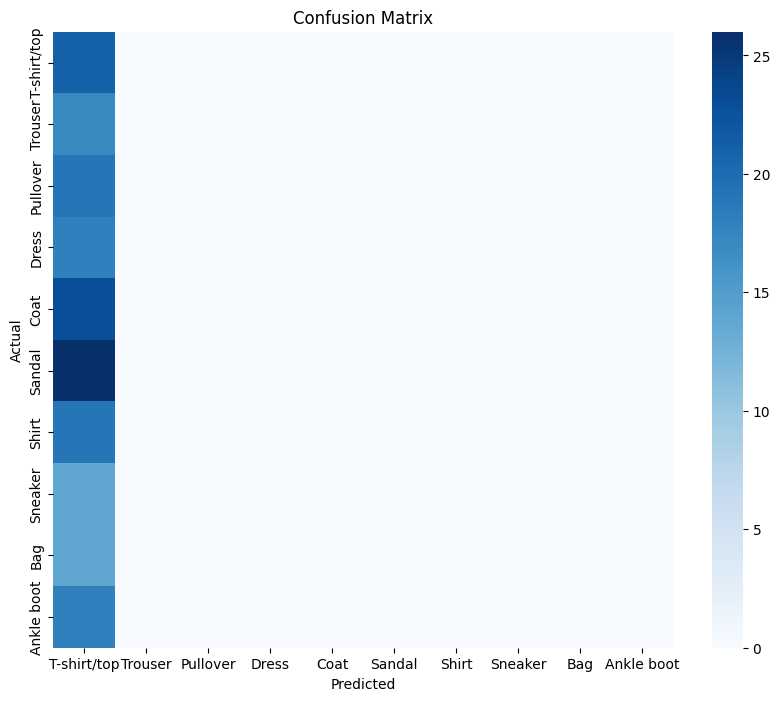

In [9]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [10]:
print("\nClassification Report\n")
print(classification_report(all_labels, all_preds, target_names=classes))



Classification Report

              precision    recall  f1-score   support

 T-shirt/top       0.11      1.00      0.20        21
     Trouser       0.00      0.00      0.00        17
    Pullover       0.00      0.00      0.00        19
       Dress       0.00      0.00      0.00        18
        Coat       0.00      0.00      0.00        23
      Sandal       0.00      0.00      0.00        26
       Shirt       0.00      0.00      0.00        19
     Sneaker       0.00      0.00      0.00        14
         Bag       0.00      0.00      0.00        14
  Ankle boot       0.00      0.00      0.00        18

    accuracy                           0.11       189
   macro avg       0.01      0.10      0.02       189
weighted avg       0.01      0.11      0.02       189



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


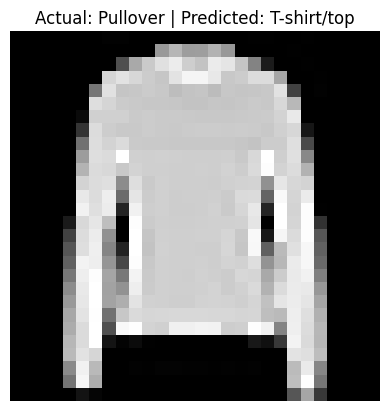

In [11]:
img, label = testset[0]

with torch.no_grad():
    pred = model(img.unsqueeze(0))
    predicted = torch.argmax(pred).item()

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Actual: {classes[label]} | Predicted: {classes[predicted]}")
plt.axis("off")
plt.show()
